## 运行环境要求

In [ ]:
!uv add scikit-learn matplotlib mlxtend bayesian-optimization seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 3.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.6 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlibm━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [scikit-learn]
    Found existing installation: matplotlib 3.10.6━━━━━━━━━━━━ 1/5 [scikit-learn]
    Uninstalling matplotlib-3.10.6:━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.6━━━━━━━━━━━━━━━━━━ 2/5 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [bayesian-optimization]lotlib]


# SVM鸢尾花分类

## 1. 导入所需库
- **numpy**：数值计算,支持复杂的数学运算，如矩阵运算、傅里叶变换、线性代数等,作为底层数据处理工具，高效地存储和操作大规模数据。
- **matplotlib**：数据可视化
- **sklearn**：机器学习工具库, 封装。
- **mlxtend**：扩展可视化功能

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from mlxtend.plotting import plot_decision_regions

 ## 2. 加载并准备数据
 - 使用鸢尾花数据集（Iris）
 - **特征选择**：只保留第0列（萼片长度）和第2列（花瓣长度），便于二维可视化
 - 标签对应3种鸢尾花品种（0: setosa, 1: versicolor, 2: virginica）

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

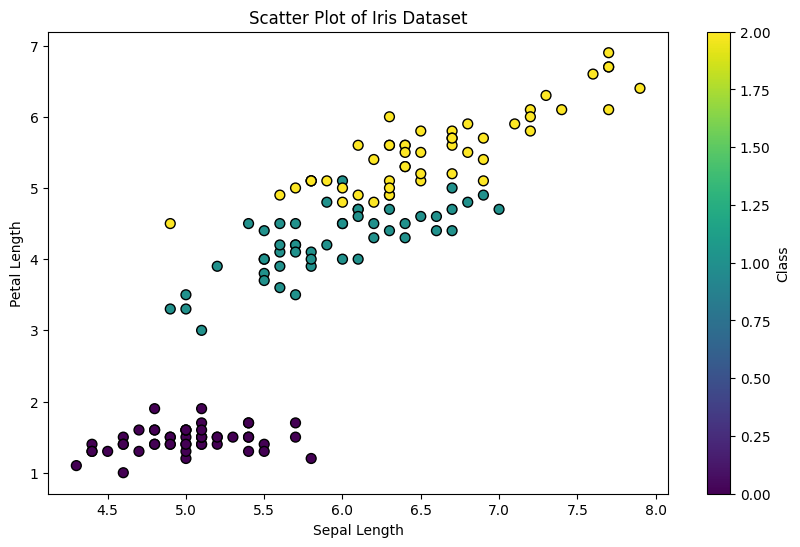

In [4]:
# 加载数据
iris = datasets.load_iris()
X = iris.data[:, [0, 2]]  # 选择萼片长度和花瓣长度两个特征,二维数组
y = iris.target
print(iris.data)
print(X.shape)
print(y.shape)
# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50) #参数决定散点图的样子
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Scatter Plot of Iris Dataset')
plt.colorbar(label='Class')
plt.show()

## 3. 划分训练集/测试集
 - **test_size=0.3**：30%数据作为测试集
 - **random_state=42**：固定随机种子保证结果可复现

In [6]:
# 划分数据集，sklearn中将数据集划分成训练集和测试集的方法，test_size=0.3表示测试集占总数据集的百分之30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 查看划分结果
print("训练集样本数:", len(X_train))
print("测试集样本数:", len(X_test))

训练集样本数: 105
测试集样本数: 45


## 4. 创建模型与交叉验证
 - **kernel='linear'**：使用线性核函数
 - **C=1**：正则化参数
 - **cv=5**：5折交叉验证
 - **scoring='accuracy'**：评估指标为准确率

In [7]:
# 创建模型并进行交叉验证
# 超参数：核函数（kernel），惩罚系数C，越大的C越倾向于正确分类样本，对于噪声数据点的容忍度越低
model = SVC(kernel='linear', C=1)
# 交叉验证：将整个数据集拆分成cv=5个子集，进行五次迭代，每次使用不同的一个子集作为验证集，使用scoring中指定的方法作为评估指标
# 交叉验证用于评估模型的性能，测试模型在不同子集上的表现，了解模型性能的稳定性以及泛化性如何
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"交叉验证准确率: {scores.mean():.2f} ± {scores.std():.2f}")

交叉验证准确率: 0.94 ± 0.04


## 5. 训练模型与可视化
 - **plot_decision_regions**：绘制决策区域
 - 注意：仅展示训练集上的决策边界

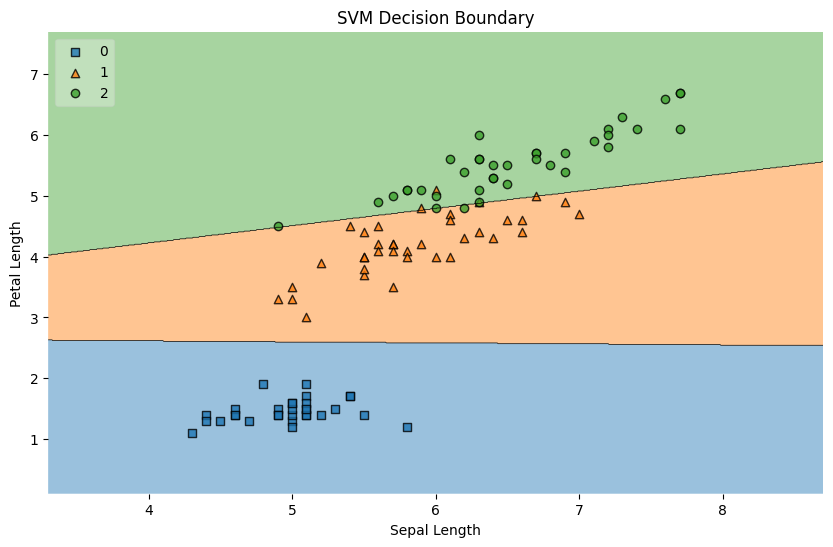

In [8]:
# 训练模型并可视化决策边界
model.fit(X_train, y_train)
plt.figure(figsize=(10,6))
# 专门用于可视化分类器决策边界的函数。这个函数可以帮助我们直观地看到分类器如何在特征空间中划分不同类别的区域。
plot_decision_regions(X_train, y_train, clf=model, legend=2)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('SVM Decision Boundary')
plt.show()

## 6. 模型评估与分类报告
 - **classification_report**：输出精确率/召回率/F1值
 - 特别关注每个类别的指标和加权平均值

In [10]:
# 在测试集上进行预测
y_pred = model.predict(X_test)
# 生成分类报告
report = classification_report(
    y_true=y_test,
    y_pred=y_pred,
    target_names=iris.target_names  # 显示类别名称
)
# 打印报告
print("分类性能报告:")
print(report)

分类性能报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



# 🎓 PCA 与特征选择对比实验（SVM分类器）

本实验通过使用鸢尾花数据集，比较两种特征降维方式（特征选择 vs PCA）对支持向量机分类器性能的影响，并对 PCA 后的分类边界进行可视化。

---

## 📦 第一步：导入必要的库

我们将用到 scikit-learn 的 PCA、SelectKBest、SVC 和管道工具 Pipeline，以及 `mlxtend` 中用于决策边界可视化的工具。

## 🌼 第二步：加载鸢尾花数据集

我们使用 `sklearn.datasets` 中的经典 `iris` 数据集，其中包含 4 个特征和 3 类标签。


In [11]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# 使用原始鸢尾花全部4个特征
X = iris.data
y = iris.target
print(X.shape)
print(y.shape)

(150, 4)
(150,)


## 🛠️ 第三步：构建两个预处理 + 模型管道

我们创建两个不同的数据处理流程：

- **特征选择管道**：使用 `SelectKBest` 选择最相关的两个原始特征；
- **PCA管道**：使用 `PCA` 将所有特征线性组合为两个主成分（无监督降维）。


In [13]:
# 特征选择管道，顺序执行管道内的数据处理和模型训练方法，数据自动传递
# selectKBest 基于方法分析ANOVA去评估特征和目标变量之间的关系进行特征选择，k=2表示选择最重要的两个特征
pipe_select = Pipeline([
    ('selector', SelectKBest(f_classif, k=2)),  # 根据评分函数选择最佳2个特征
    ('svm', SVC(kernel='linear',C=1))
])

# 特征提取管道
pipe_extract = Pipeline([
    ('pca', PCA(n_components=2)),  # 降维到2个主成分
    ('svm', SVC(kernel='linear',C=1))
])

## 📈 第四步：模型性能对比

使用 5 折交叉验证，比较两种降维方式对模型准确率的影响。我们将输出平均准确率及标准差：

In [14]:
# 对比性能
for name, model in [('Feature Selection', pipe_select), ('PCA', pipe_extract)]:
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} 准确率: {scores.mean():.2f} ± {scores.std():.2f}")

Feature Selection 准确率: 0.96 ± 0.02
PCA 准确率: 0.97 ± 0.03


## 🎨 第五步：PCA 降维后的可视化决策边界

我们使用 PCA 提取的两个主成分，在二维平面上绘制 SVM 的分类边界。

注意：
- 主成分不是原始特征的子集，而是它们的线性组合；
- 可视化有助于理解降维在分类任务中的效果。

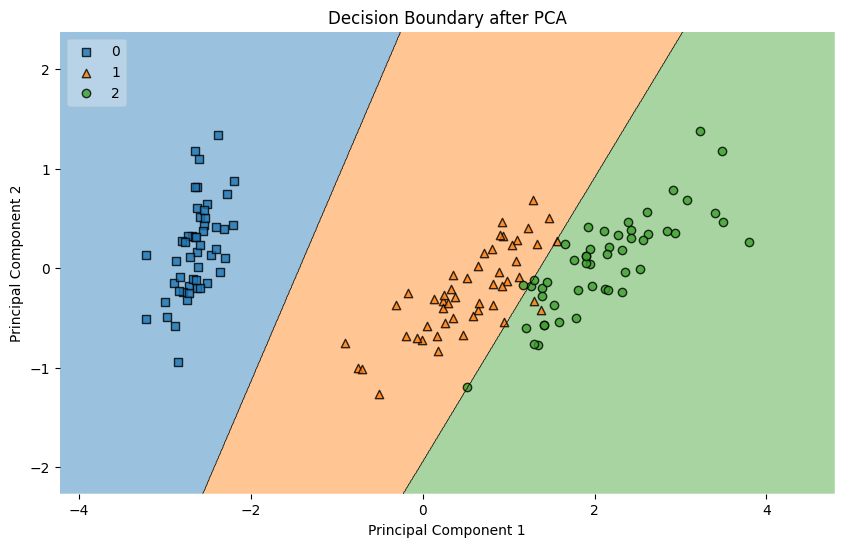

In [15]:
# 拟合 PCA 管道以获取主成分
pipe_extract.fit(X, y)

# 从pipeline中按照名字取出特定步骤，使用 PCA 变换后的数据用于可视化
X_transformed = pipe_extract.named_steps['pca'].transform(X)

# 获取拟合后的 SVM 模型
svm_model = pipe_extract.named_steps['svm']

# 可视化决策边界
plt.figure(figsize=(10,6))
plot_decision_regions(X_transformed, y, clf=svm_model, legend=2)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Decision Boundary after PCA')
plt.show()

# SVM 超参数调优与可视化教学

本教程将通过使用支持向量机（SVM），演示如何进行超参数网格搜索调优，并通过图形可视化不同核函数的分类边界。

---

## 📦 第一步：导入所需的 Python 库

我们将使用 `scikit-learn` 提供的 SVM 实现与网格搜索功能，配合 `matplotlib` 和 `mlxtend` 来绘制决策边界。

## 🛠️ 第二步：网格搜索调参

我们通过 `GridSearchCV` 对 SVM 的多个超参数组合进行交叉验证，寻找最优配置。主要调节的参数包括：

- `kernel`: 核函数类型（linear, rbf, poly）
- `C`: 正则化参数。正则化的强度与 C 成反比。C 越大，对误分类的惩罚越大，模型对训练数据的拟合越好，但可能导致过拟合；C 越小，模型对误分类的容忍度越高，泛化能力更强
- `gamma`: 控制样本影响范围的参数（仅用于非线性核）当 `gamma='scale'` 时，gamma 的值计算如下：$\gamma=\frac{1}{n_{\mathrm{features}}\times\mathrm{X.var}()}$；`gamma='auto'` 时的计算公式：$\gamma=\frac{1}{n_{\mathrm{features}}}$
---


In [16]:
from sklearn.model_selection import GridSearchCV

# 参数网格
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# 网格搜索
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# 输出最佳参数
print(f"最佳参数: {grid.best_params_}")
print(f"最佳准确率: {grid.best_score_:.2f}")

最佳参数: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
最佳准确率: 0.96


## 🎨 第三步：可视化不同核函数的分类边界

我们固定 `C=1` 和 `gamma='scale'`，观察不同核函数（linear, rbf, poly）对数据分类边界的影响。

- 线性核适合线性可分的数据
- RBF 核能捕捉更复杂的非线性结构
- 多项式核表现形式可调，适用于特定分布

通过直观的决策边界图，我们可以更好地理解核函数在特征空间中的作用。

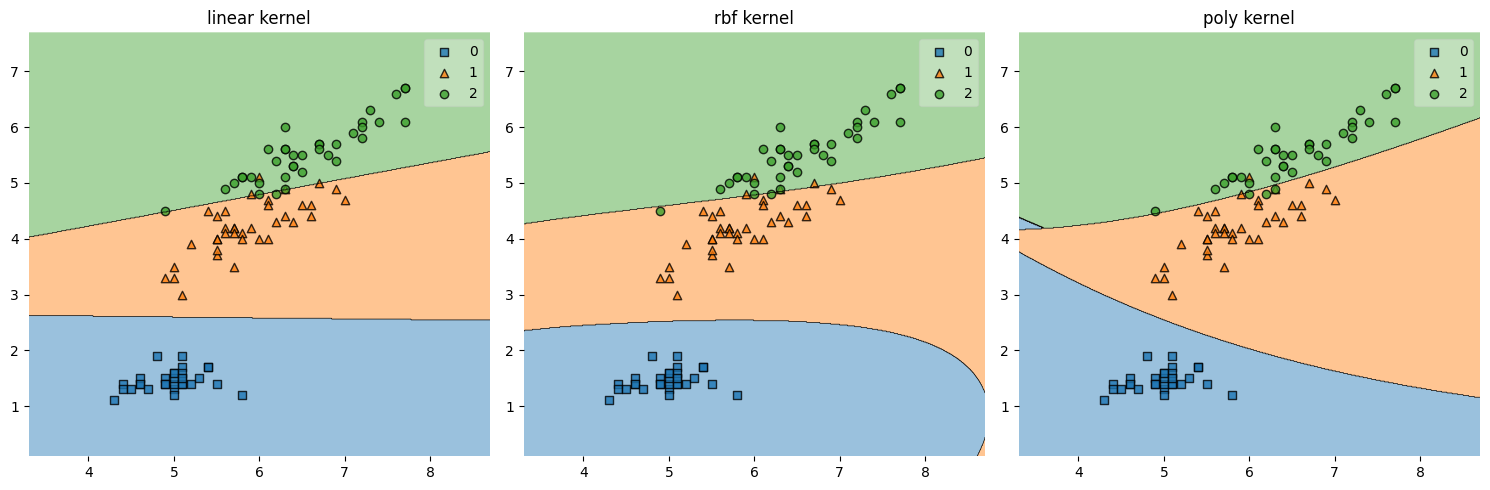

In [17]:
# 可视化不同核函数效果
plt.figure(figsize=(15,5))
for i, kernel in enumerate(['linear', 'rbf', 'poly'], 1):
    model = SVC(kernel=kernel, C=1, gamma='scale')
    model.fit(X_train, y_train)
    plt.subplot(1,3,i)
    plot_decision_regions(X_train, y_train, clf=model)
    plt.title(f'{kernel} kernel')
plt.tight_layout()
plt.show()

# ⚙️ SVR 原理简介（支持向量回归）

SVR 是对 SVM（支持向量机）在回归任务中的扩展，目标是找到一个函数，使其在误差不超过 ε 的范围内预测目标值。

## 核心思想如下：

1. **ε-不敏感损失函数**：
   - 对于预测值与真实值之间误差在 ε 以内的样本，不计入损失；
   - 超出 ε 的部分才算误差。

2. **优化目标**：
   - 找到最平滑的函数（即具有最小范数的函数）；
   - 同时使大多数训练样本的预测误差都在 ε 范围内。

3. **核技巧（kernel trick）**：
   - 可以在高维空间中进行线性建模（例如 RBF 核）；
   - 实际上可以建模非线性关系。

4. **支持向量**：
   - 只有那些在 ε 管外的样本才会成为支持向量，对最终模型有影响。

其实就是在误差范围内找到一个最优“管道”，使得大多数点都落在这个管道中。

## 常用参数：
- `C`: 控制对超出 ε 区域样本的惩罚程度；
- `epsilon`: 允许的误差容忍范围；
- `kernel`: 常用有 `'linear'`, `'rbf'`, `'poly'` 等；
- `gamma`: 控制 RBF 核函数的“宽度”。

SVR 模型适合用于非线性关系建模，尤其在特征较少、数据规模中等的情况下表现良好。


# 🏡 SVR 实现房价预测（加州房价数据集）

本实验使用支持向量回归（SVR）模型来预测加州的房价，通过简单的特征选择、模型训练与评估，展示 SVR 在回归任务中的应用。

---

## 🛠 第一步：导入必要的库

我们需要：
- `SVR`: 支持向量回归模型；
- `fetch_california_housing`: 加载房价数据集；
- `mean_squared_error`, `r2_score`: 用于模型性能评估
- `train_test_split`: 用于训练集和测试集划分；
- `matplotlib`: 绘图可视化。

## 📊 第二步：加载数据集与特征选择

我们使用 `sklearn` 提供的加州房价数据集。该数据集包含多个影响房价的因素。

为了简化问题，我们仅选择两个重要特征：
- `MedInc`（人均收入）
- `AveRooms`（平均房间数）

这样便于观察 SVR 对回归问题的处理效果。


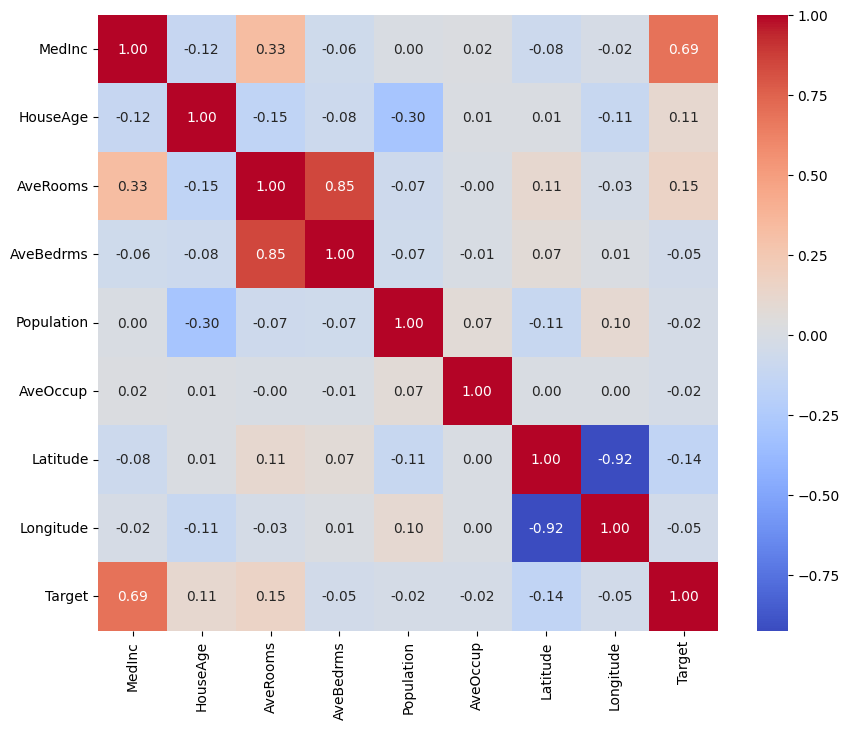

In [18]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import seaborn as sns

# 加载加州房价数据集
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

# 转换为 DataFrame 并保存
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y
# 相关性分析（热力图）
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# df.to_csv('california_housing.csv', index=False)
# print("✅ 数据集已保存为 california_housing.csv")


## ✂️ 第三步：划分训练集与测试集

我们使用 80% 的数据训练模型，20% 的数据用于测试。这样可以评估模型的泛化能力。


In [19]:
# 划分数据集
X = X[:, [0, 5]]  # 选择人均收入与平均房间数
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🔧 第四步：训练 SVR 模型

我们使用核函数为 RBF（高斯核）的 SVR 模型进行训练。主要参数说明如下：

- `C=100`: 惩罚参数，控制对误差的容忍程度；
- `gamma=0.1`: 核函数的参数，决定每个样本的“影响范围”；
- `epsilon=0.1`: ε-不敏感区间，预测值在该区间范围内不会产生损失。

这些超参数可通过网格搜索进一步调优。

In [20]:
# 训练SVR模型
# model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
# model.fit(X_train, y_train)
# # 保存模型
import joblib  # 如果用的是较新版本 sklearn，直接用 joblib 包
# # joblib.dump(model, 'svr_model.pkl')

# 加载模型
loaded_model = joblib.load('svr_model.pkl')

# 使用加载后的模型进行预测
y_pred = loaded_model.predict(X_test)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 📈 第五步：模型预测与评估

我们使用两个常见的回归评价指标：
- **MSE（均方误差）**：预测值与真实值之间的误差平方的平均值；$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ 
- **RMSE (均方根误差)**: $\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$; 
- **R²（决定系数）**：越接近 1 表示模型解释力越强。$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$ 适用于评估模型的整体拟合优度

In [21]:
# 预测与评估
y_pred = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

MSE: 4.16
RMSE: 2.039791274092726
R²: -2.18


## 🎨 第六步：可视化预测结果

我们绘制预测值 vs. 真实值的散点图：

- 理想情况是所有点落在对角线 `y=x` 上；
- 点越接近对角线，说明模型预测效果越好。

[0.477   0.458   5.00001 ... 5.00001 0.723   1.515  ]


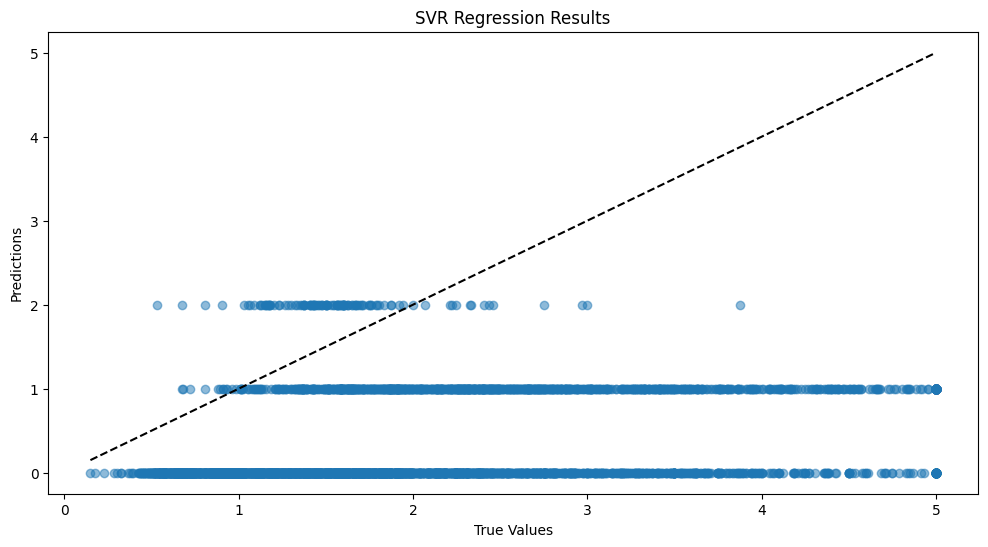

In [22]:
# 回归预测的可视化结果，横轴表示样本真实值，纵轴表示样本预测值
# 对角线是y=x，越多的点落在对角线上或者越多的点距离对角线比较近的话，说明预测值和真实值比较相近，说明回归的算法效果比较好。
print(y_test)
plt.figure(figsize=(12,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('SVR Regression Results')
plt.show()

## SVR调参

In [23]:
#加载数据集
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X, y = housing.data, housing.target

In [24]:
#特征选择
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=2)
X_selected = selector.fit_transform(X, y)

In [25]:
#特征提取
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [1, 10],
    'gamma': ['scale'],
    'epsilon': [0.1, 0.2, 0.5]
}
grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3)
grid.fit(X_selected, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10], 'epsilon': [0.1, 0.2, ...], 'gamma': ['scale']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from scipy.stats import uniform

# 定义参数分布（你也可以使用列表，但使用概率分布能更好地随机采样）
param_distributions = {
    'C': uniform(1, 100),            # 从1到100之间均匀采样
    'gamma': ['scale', 'auto'],      # 也可以设定为连续分布
    'epsilon': uniform(0.01, 0.5),   # 从0.01到0.51之间采样
}

# 构造随机搜索对象
random_search = RandomizedSearchCV(
    SVR(kernel='rbf'),
    param_distributions=param_distributions,
    n_iter=2,     # 采样20组参数，越大越全面但越慢
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1       # 并行加速
)

# 执行搜索
random_search.fit(X_selected, y)

# 输出最优参数
print("Best Parameters:", random_search.best_params_)
print("Best R² Score:", random_search.best_score_)


Best Parameters: {'C': np.float64(38.454011884736246), 'epsilon': np.float64(0.4853571532049581), 'gamma': 'scale'}
Best R² Score: 0.524492801707478


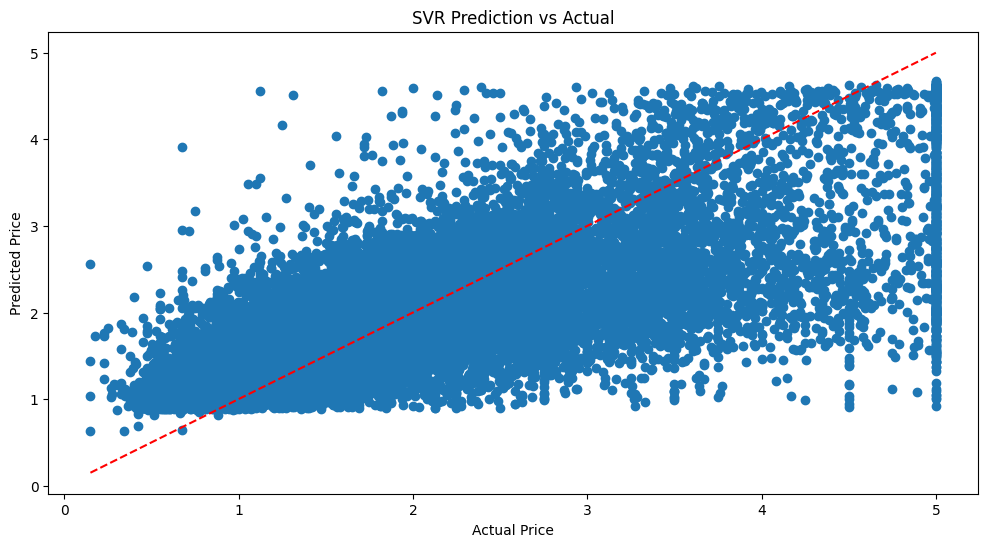

In [28]:
import matplotlib.pyplot as plt
# y_pred = grid.predict(X_selected)
y_pred = random_search.predict(X_selected)

plt.figure(figsize=(12,6))
plt.scatter(y, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR Prediction vs Actual")
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')
plt.show()